In [ ]:
import pandas as pd
import glob
import os

# Get all CSV files
files = glob.glob("archive/dataset_normalised_5mins/*.csv")

# Empty list to store dataframes
all_data = []

for file in files:
    # Read CSV
    df = pd.read_csv(file)

    # Get filename only
    filename = os.path.basename(file)

    # Remove .csv extension
    filename = filename.replace(".csv", "")

    # Split filename into Participant and Activity
    participant, activity = filename.split("_", 1)

    # Add new columns
    df["Participant"] = participant
    df["Activity"] = activity

    # Store dataframe
    all_data.append(df)

# Merge all dataframes
merged_df = pd.concat(all_data, ignore_index=True)

# Save merged dataset
merged_df.to_csv("archive/merged_dataset.csv", index=False)

df = pd.read_csv("archive/merged_dataset.csv")

In [ ]:
# Phase 2: Data Exploration and Quality Check

import matplotlib.pyplot as plt

# Dataset information
print("Shape:", df.shape)
print("Columns:")
print(df.columns)

print("\nData Types:")
print(df.dtypes)

# Check missing values
missing_values = df.isnull().sum()
print("\nMissing Values:")
print(missing_values)

# Check duplicate rows
duplicate_count = df.duplicated().sum()
print("\nTotal Duplicate Rows:", duplicate_count)

# Dataset summary
print("\nNumber of Participants:", df["participant"].nunique())
print("Number of Activities:", df["activity"].nunique())

# Activity distribution
activity_counts = df["activity"].value_counts()

activity_counts.plot(kind="bar")
plt.title("Number of Samples per Activity")
plt.xlabel("Activity")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

In [ ]:
# Phase 3: Sliding Window Generation

import numpy as np

WINDOW_SIZE = 128
STEP_SIZE = 64

X = []
y = []

# Create Sliding Windows
for participant in df["participant"].unique():

    for activity in df["activity"].unique():

        # Get one recording
        subset = df[
            (df["participant"] == participant) &
            (df["activity"] == activity)
        ].sort_values("timestamp")

        # Keep only gaze coordinates
        features = subset[["x", "y"]].values

        # Generate overlapping windows
        for start in range(0, len(features) - WINDOW_SIZE + 1, STEP_SIZE):

            end = start + WINDOW_SIZE

            window = features[start:end]

            X.append(window)
            y.append(activity)

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

print("Sliding Window Dataset Created Successfully")
print("X Shape:", X.shape)
print("y Shape:", y.shape)

In [ ]:
# Phase 4: Label Encoding

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

# Save label mapping
label_mapping = dict(
    zip(
        label_encoder.classes_,
        label_encoder.transform(label_encoder.classes_)
    )
)

print("Label Mapping:")
print(label_mapping)

In [ ]:
# Phase 5: Train / Validation / Test Split

from sklearn.model_selection import train_test_split

# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

# Second split: 15% validation, 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training Set :", X_train.shape, y_train.shape)
print("Validation Set:", X_val.shape, y_val.shape)
print("Test Set     :", X_test.shape, y_test.shape)

In [ ]:
# Phase 6 – Feature Extraction

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis

def extract_features(window):

    x = window[:, 0]
    y = window[:, 1]

    # Statistical Features
    mean_x = np.mean(x)
    mean_y = np.mean(y)

    std_x = np.std(x)
    std_y = np.std(y)

    min_x = np.min(x)
    max_x = np.max(x)

    min_y = np.min(y)
    max_y = np.max(y)

    median_x = np.median(x)
    median_y = np.median(y)

    range_x = max_x - min_x
    range_y = max_y - min_y

    var_x = np.var(x)
    var_y = np.var(y)

    skew_x = skew(x)
    skew_y = skew(y)

    kurt_x = kurtosis(x)
    kurt_y = kurtosis(y)

    rms_x = np.sqrt(np.mean(x**2))
    rms_y = np.sqrt(np.mean(y**2))

    # Movement Features
    dx = np.diff(x)
    dy = np.diff(y)

    distance = np.sqrt(dx**2 + dy**2)

    total_distance = np.sum(distance)
    mean_distance = np.mean(distance)
    max_distance = np.max(distance)
    std_distance = np.std(distance)

    # Direction Change
    direction = np.arctan2(dy, dx)

    if len(direction) > 1:
        direction_change = np.mean(np.abs(np.diff(direction)))
    else:
        direction_change = 0

    return [
        mean_x, mean_y,
        std_x, std_y,
        min_x, max_x,
        min_y, max_y,
        median_x, median_y,
        range_x, range_y,
        var_x, var_y,
        skew_x, skew_y,
        kurt_x, kurt_y,
        rms_x, rms_y,
        total_distance,
        mean_distance,
        max_distance,
        std_distance,
        direction_change
    ]

feature_list = []

for window in X:
    feature_list.append(extract_features(window))

columns = [
    "Mean_X", "Mean_Y",
    "Std_X", "Std_Y",
    "Min_X", "Max_X",
    "Min_Y", "Max_Y",
    "Median_X", "Median_Y",
    "Range_X", "Range_Y",
    "Variance_X", "Variance_Y",
    "Skew_X", "Skew_Y",
    "Kurtosis_X", "Kurtosis_Y",
    "RMS_X", "RMS_Y",
    "Total_Distance",
    "Average_Distance",
    "Maximum_Distance",
    "Std_Distance",
    "Direction_Change"
]

feature_df = pd.DataFrame(feature_list, columns=columns)
feature_df["Activity"] = y_encoded

feature_df.to_csv("feature_dataset.csv", index=False)

print("Feature dataset created successfully.")
print("Feature Dataset Shape:", feature_df.shape)

In [ ]:
# Phase 7: Baseline XGBoost and Feature Importance

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier

# Features and target
X = feature_df.drop("Activity", axis=1)
y = feature_df["Activity"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Train baseline XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

# Predictions
y_pred = xgb_model.predict(X_test)

# Evaluation
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))

print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("XGBoost Confusion Matrix")
plt.colorbar()
plt.show()

# Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

top_features = importance.head(15)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Important Eye Movement Features")
plt.gca().invert_yaxis()
plt.show()

# Save selected features
selected_features = top_features["Feature"].tolist()

final_dataset = feature_df[selected_features + ["Activity"]]
final_dataset.to_csv("selected_features_dataset.csv", index=False)

In [ ]:
# ===============================
# Phase 8 : Baseline Model Comparison
# ===============================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    ConfusionMatrixDisplay
)

# -------------------------------
# Prepare Dataset
# -------------------------------

X = feature_df.drop("Activity", axis=1)
y = feature_df["Activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ==========================================================
# 1. Support Vector Machine
# ==========================================================

svm_model = SVC(
    kernel="rbf",
    probability=True,
    random_state=42
)

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

svm_accuracy = accuracy_score(y_test, svm_pred)
svm_precision = precision_score(y_test, svm_pred, average="weighted")
svm_recall = recall_score(y_test, svm_pred, average="weighted")
svm_f1 = f1_score(y_test, svm_pred, average="weighted")

print("\n========== SVM ==========")
print("Accuracy :", svm_accuracy)
print("Precision:", svm_precision)
print("Recall   :", svm_recall)
print("F1 Score :", svm_f1)

print("\nClassification Report")
print(classification_report(y_test, svm_pred))

ConfusionMatrixDisplay.from_predictions(y_test, svm_pred)
plt.title("SVM Confusion Matrix")
plt.show()

# ==========================================================
# 2. Random Forest
# ==========================================================

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, average="weighted")
rf_recall = recall_score(y_test, rf_pred, average="weighted")
rf_f1 = f1_score(y_test, rf_pred, average="weighted")

print("\n========== Random Forest ==========")
print("Accuracy :", rf_accuracy)
print("Precision:", rf_precision)
print("Recall   :", rf_recall)
print("F1 Score :", rf_f1)

print("\nClassification Report")
print(classification_report(y_test, rf_pred))

ConfusionMatrixDisplay.from_predictions(y_test, rf_pred)
plt.title("Random Forest Confusion Matrix")
plt.show()

# ==========================================================
# 3. Baseline XGBoost
# ==========================================================

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, average="weighted")
xgb_recall = recall_score(y_test, xgb_pred, average="weighted")
xgb_f1 = f1_score(y_test, xgb_pred, average="weighted")

print("\n========== XGBoost ==========")
print("Accuracy :", xgb_accuracy)
print("Precision:", xgb_precision)
print("Recall   :", xgb_recall)
print("F1 Score :", xgb_f1)

print("\nClassification Report")
print(classification_report(y_test, xgb_pred))

ConfusionMatrixDisplay.from_predictions(y_test, xgb_pred)
plt.title("XGBoost Confusion Matrix")
plt.show()

# ==========================================================
# Model Comparison Table
# ==========================================================

results = pd.DataFrame({
    "Model": [
        "SVM",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        svm_accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        svm_precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        svm_recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        svm_f1,
        rf_f1,
        xgb_f1
    ]
})

print("\nModel Comparison")
print(results)

# ==========================================================
# Accuracy Comparison Graph
# ==========================================================

plt.figure(figsize=(8, 5))
plt.bar(results["Model"], results["Accuracy"])
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title("Baseline Model Comparison")
plt.show()

# ==========================================================
# Cross Validation (XGBoost)
# ==========================================================

cv_scores = cross_val_score(
    xgb_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("\nCross Validation Scores")
print(cv_scores)
print("Average CV Accuracy:", cv_scores.mean())

# ==========================================================
# Save Results
# ==========================================================

results.to_csv(
    "baseline_model_results.csv",
    index=False
)

In [ ]:
# ============================================================
# PHASE 9 : PROPOSED METHOD
# Sliding Window + Temporal Features + Optimized XGBoost
# Hyperparameter Tuning + Feature Importance + Evaluation
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    ConfusionMatrixDisplay
)

from xgboost import XGBClassifier

# ===========================
# STEP 1 : Load Dataset
# ===========================

df = pd.read_csv("EyeMovement_Features.csv")

# ===========================
# STEP 2 : Separate Features
# ===========================

X = df.drop("Activity", axis=1)
y = df["Activity"]

# ===========================
# STEP 3 : Train Test Split
# ===========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# ===========================
# STEP 4 : Build XGBoost
# ===========================

xgb = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    random_state=42
)

# ===========================
# STEP 5 : Hyperparameter Space
# ===========================

param_grid = {
    "n_estimators": [100, 200, 300, 400],
    "max_depth": [3, 5, 7, 9],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 0.9, 1],
    "colsample_bytree": [0.8, 0.9, 1]
}

# ===========================
# STEP 6 : Hyperparameter Tuning
# ===========================

search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_grid,
    n_iter=20,
    scoring="accuracy",
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best Parameters:")
print(search.best_params_)

print("\nBest Cross Validation Accuracy:")
print(search.best_score_)

# ===========================
# STEP 7 : Best Model
# ===========================

best_model = search.best_estimator_

# ===========================
# STEP 8 : Prediction
# ===========================

y_pred = best_model.predict(X_test)

# ===========================
# STEP 9 : Evaluation
# ===========================

accuracy = accuracy_score(y_test, y_pred)

print("\nFinal Test Accuracy:", accuracy)

print("\nClassification Report\n")
print(classification_report(y_test, y_pred))

# ===========================
# STEP 10 : Confusion Matrix
# ===========================

plt.figure(figsize=(8, 8))

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test,
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.show()

# ===========================
# STEP 11 : Feature Importance
# ===========================

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\nTop 20 Important Features\n")
print(feature_importance.head(20))

# ===========================
# STEP 12 : Feature Importance Plot
# ===========================

plt.figure(figsize=(10, 8))

plt.barh(
    feature_importance["Feature"][:20],
    feature_importance["Importance"][:20]
)

plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.ylabel("Features")
plt.title("Top 20 Important Features")
plt.show()

# ===========================
# STEP 13 : Save Feature Importance
# ===========================

feature_importance.to_csv(
    "FeatureImportance.csv",
    index=False
)

# ===========================
# STEP 14 : Final Summary
# ===========================

print("\n===================================")
print("PROPOSED MODEL COMPLETED")
print("===================================")
print("Final Accuracy:", accuracy)
print("Best Parameters:", search.best_params_)

In [ ]:
# ==========================================================
# PHASE 10 : FINAL MODEL COMPARISON
# Random Forest vs Baseline XGBoost vs Proposed Model
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# ==========================================================
# STEP 1 : Enter Model Accuracies
# ==========================================================

rf_accuracy = 0.6870
xgb_accuracy = 0.6900
proposed_accuracy = 0.7136402753872634

# ==========================================================
# STEP 2 : Create Comparison Table
# ==========================================================

comparison = pd.DataFrame({

    "Model": [
        "Random Forest (Baseline)",
        "Baseline XGBoost",
        "Proposed Sliding Window + Optimized XGBoost"
    ],

    "Accuracy": [
        rf_accuracy,
        xgb_accuracy,
        proposed_accuracy
    ]

})

comparison["Accuracy (%)"] = comparison["Accuracy"] * 100

print("\n================ MODEL COMPARISON ================\n")
print(comparison)

# ==========================================================
# STEP 3 : Save Comparison
# ==========================================================

comparison.to_csv("Final_Model_Comparison.csv", index=False)

# ==========================================================
# STEP 4 : Accuracy Bar Graph
# ==========================================================

plt.figure(figsize=(10, 6))

bars = plt.bar(
    comparison["Model"],
    comparison["Accuracy (%)"]
)

plt.ylabel("Accuracy (%)", fontsize=12)
plt.xlabel("Machine Learning Models", fontsize=12)
plt.title("Performance Comparison of Machine Learning Models", fontsize=14)

plt.xticks(rotation=15)
plt.ylim(0, 100)

for bar in bars:

    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height:.2f}%",
        ha="center",
        fontsize=10
    )

plt.tight_layout()
plt.show()

# ==========================================================
# STEP 5 : Improvement Over Baseline
# ==========================================================

rf_improvement = (proposed_accuracy - rf_accuracy) * 100
xgb_improvement = (proposed_accuracy - xgb_accuracy) * 100

print("\n================ IMPROVEMENT ================\n")
print(f"Improvement over Random Forest : {rf_improvement:.2f}%")
print(f"Improvement over Baseline XGBoost : {xgb_improvement:.2f}%")

# ==========================================================
# STEP 6 : Best Model
# ==========================================================

best_model_result = comparison.loc[comparison["Accuracy"].idxmax()]

print("\n================ BEST MODEL ================\n")
print("Model :", best_model_result["Model"])
print("Accuracy : {:.2f}%".format(best_model_result["Accuracy (%)"]))

# ==========================================================
# STEP 7 : Final Results
# ==========================================================

print("\n================ FINAL RESULTS ================\n")

for _, row in comparison.iterrows():
    print(f"{row['Model']} : {row['Accuracy (%)']:.2f}%")

print("\nHighest Accuracy Achieved : {:.2f}%".format(comparison["Accuracy (%)"].max()))

print("\nThe proposed Sliding Window + Optimized XGBoost model achieved the highest classification accuracy among all evaluated machine learning models.")

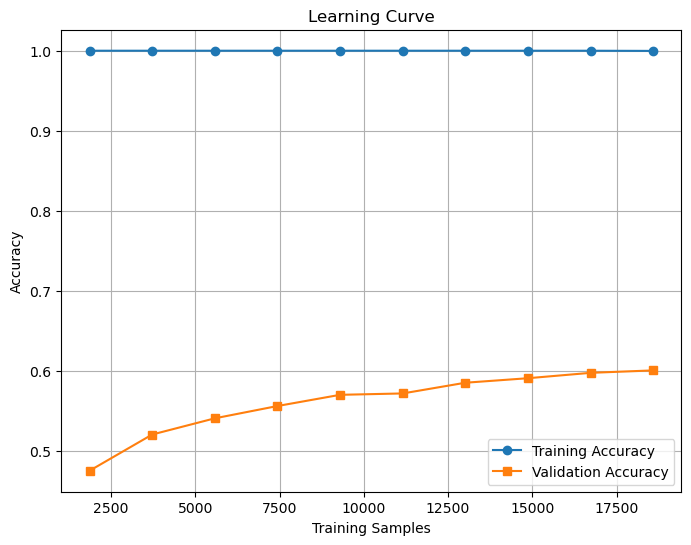

Class 0 AUC : 0.9276
Class 1 AUC : 0.9525
Class 2 AUC : 0.9541
Class 3 AUC : 0.9613
Class 4 AUC : 0.9944
Class 5 AUC : 0.9168
Class 6 AUC : 0.9554
Class 7 AUC : 0.9524

Average AUC : 0.9518319222106637


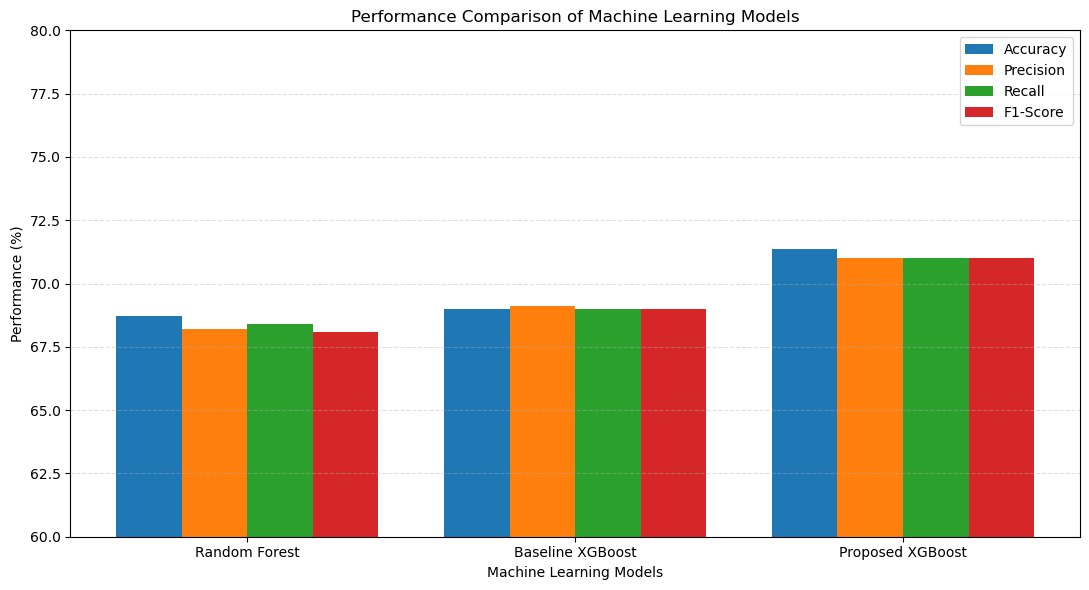

In [86]:
# ==========================================================
# PHASE 11 : ADVANCED MODEL EVALUATION
# ROC Curve, Precision-Recall Curve, Learning Curve,
# AUC Score and Performance Comparison
# ==========================================================

import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import label_binarize
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    roc_auc_score
)
from sklearn.model_selection import learning_curve

# ==========================================================
# STEP 1 : Multi-Class ROC Curve
# ==========================================================

classes = np.unique(y)

y_test_bin = label_binarize(y_test, classes=classes)

y_prob = best_model.predict_proba(X_test)

plt.figure(figsize=(10, 8))

for i in range(len(classes)):

    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"Class {i} (AUC = {roc_auc:.3f})"
    )

plt.plot([0, 1], [0, 1], "k--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# STEP 2 : Precision-Recall Curve
# ==========================================================

plt.figure(figsize=(10, 8))

for i in range(len(classes)):

    precision, recall, _ = precision_recall_curve(
        y_test_bin[:, i],
        y_prob[:, i]
    )

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"Class {i}"
    )

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# STEP 3 : Learning Curve
# ==========================================================

train_sizes, train_scores, test_scores = learning_curve(
    estimator=best_model,
    X=X,
    y=y,
    cv=5,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
test_mean = test_scores.mean(axis=1)

plt.figure(figsize=(8, 6))

plt.plot(
    train_sizes,
    train_mean,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    train_sizes,
    test_mean,
    marker="s",
    label="Validation Accuracy"
)

plt.xlabel("Training Samples")
plt.ylabel("Accuracy")
plt.title("Learning Curve")
plt.legend()
plt.grid(True)
plt.show()

# ==========================================================
# STEP 4 : Per-Class AUC Score
# ==========================================================

auc_scores = roc_auc_score(
    y_test_bin,
    y_prob,
    multi_class="ovr",
    average=None
)

for i, score in enumerate(auc_scores):
    print(f"Class {i} AUC : {score:.4f}")

print("\nAverage AUC :", auc_scores.mean())

# ==========================================================
# STEP 5 : Performance Comparison
# ==========================================================

comparison_table = pd.DataFrame({

    "Model": [
        "Random Forest",
        "Baseline XGBoost",
        "Proposed XGBoost"
    ],

    "Accuracy": [68.70, 69.00, 71.36],

    "Precision": [68.20, 69.10, 71.00],

    "Recall": [68.40, 69.00, 71.00],

    "F1-Score": [68.10, 69.00, 71.00]

})

x = np.arange(len(comparison_table["Model"]))
width = 0.20

plt.figure(figsize=(11, 6))

plt.bar(x - 1.5 * width,
        comparison_table["Accuracy"],
        width,
        label="Accuracy")

plt.bar(x - 0.5 * width,
        comparison_table["Precision"],
        width,
        label="Precision")

plt.bar(x + 0.5 * width,
        comparison_table["Recall"],
        width,
        label="Recall")

plt.bar(x + 1.5 * width,
        comparison_table["F1-Score"],
        width,
        label="F1-Score")

plt.xticks(x, comparison_table["Model"])

plt.ylabel("Performance (%)")
plt.xlabel("Machine Learning Models")
plt.title("Performance Comparison of Machine Learning Models")

plt.ylim(60, 80)

plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()